In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_data=pd.read_csv(r"C:\Users\Suman\Documents\Naresh IT\data files\Visadataset.csv")

In [3]:
num=visa_data.select_dtypes(exclude='object').columns
cat=visa_data.select_dtypes(include='object').columns
num,cat

(Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object'),
 Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
        'requires_job_training', 'region_of_employment', 'unit_of_wage',
        'full_time_position', 'case_status'],
       dtype='object'))

- we did only categorical column
- we did only numerical column
- now multiple column analysis
- lets assume continent vs case-status
- we know differernt applicants from different continents
- in that some of visa are certified or some are denied
- so visa certified and denied overall information available in case status

In [4]:
visa_data['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [5]:
visa_data['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [8]:
con1=visa_data['continent']=='Asia'    # true False
con2=visa_data['case_status']=='Certified'   # True false
certi_count=np.sum(con1&con2)

con3=visa_data['case_status']=='Denied'
deni_count=np.sum(con1&con3)
certi_count,deni_count

(np.int64(11012), np.int64(5849))

In [5]:
cont1=visa_data['continent'].value_counts().keys()

Index(['Asia', 'Europe', 'North America', 'South America', 'Africa',
       'Oceania'],
      dtype='object', name='continent')

In [23]:
cont=['Asia', 'Europe', 'North America', 'South America', 'Africa','Oceania']
c=[]
d=[]
for i in cont:
    con1=visa_data['continent']==i
    con2=visa_data['case_status']=='Certified'
    c.append(np.sum(con1&con2))

    con3=visa_data['case_status']=='Denied'
    d.append(np.sum(con1&con3))


pd.DataFrame(data=zip(c,d),columns=['Certified','Denied'],index=cont)

,Certified,Denied
Asia,11012,5849
Europe,2957,775
North America,2037,1255
South America,493,359
Africa,397,154
Oceania,122,70


## crosstab

In [ ]:
pd.crosstab(index,
    columns,
    values=None,
    rownames=None,
    colnames=None,
    aggfunc=None,
    margins: 'bool' = False,
    margins_name: 'Hashable' = 'All',
    dropna: 'bool' = True,
    normalize: "bool | Literal[0, 1, 'all', 'index', 'columns']" = False,)

In [8]:
#which column i want to choose as index
# which column i want to use as column
col1=visa_data['case_status']
col2=visa_data['continent']
col3=visa_data['education_of_employee']
pd.crosstab(col2,col1)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [9]:
pd.crosstab(col1,[col3,col2])

education_of_employee Bachelor's                                     \
continent                 Africa  Asia Europe North America Oceania   
case_status                                                           
Certified                     81  4407   1040           641      38   
Denied                        62  2761    259           584      28   

education_of_employee               Doctorate                            ...  \
continent             South America    Africa Asia Europe North America  ...   
case_status                                                              ...   
Certified                       160        43  780    788           207  ...   
Denied                          173        11  143     58            51  ...   

education_of_employee High School                                      \
continent                  Europe North America Oceania South America   
case_status                                                             
Certified                     162           210      19            74   
Denied                        328           191      17            63   

education_of_employee Master's                                     \
continent               Africa  Asia Europe North America Oceania   
case_status                                                         
Certified                  250  5149    967           979      46   
Denied                      38  1331    130           429      22   

education_of_employee                
continent             South America  
case_status                          
Certified                       184  
Denied                          109  

[2 rows x 24 columns]

In [34]:
pd.crosstab(col2,[col1,col3])

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [36]:
pd.crosstab(col3,[col2,col1])

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

## Scatter-Plot

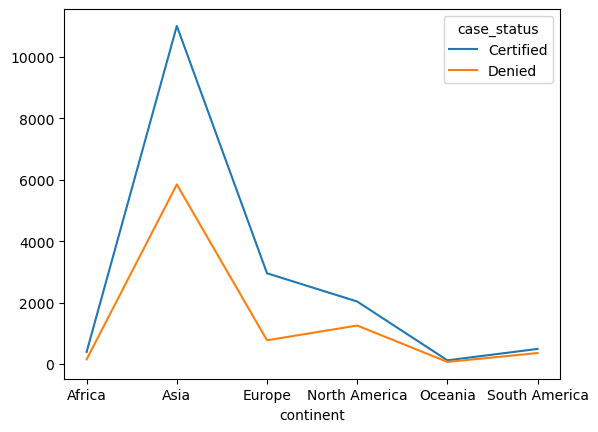

In [10]:
col1=visa_data['case_status']
col2=visa_data['continent']
r1=pd.crosstab(col2,col1)
r1.plot()
plt.show()

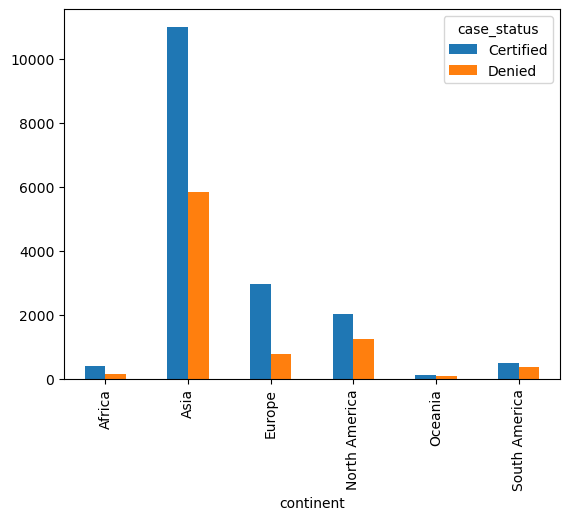

In [13]:
r1.plot(kind='bar')
plt.show()

- categrical: **Frequency table - Bar chart**
- numerical: **histogram**
- categorical vs categorical: **pd.crosstab()**
- numerical vs numerical: **scatter plots, cova, corre**

### Numerical vs Numerical

### Scatter Plots
- It is a graph representation between two numerical columns
- it is also gives the relationship status between two columns
    - positive or negative or no relation

In [44]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

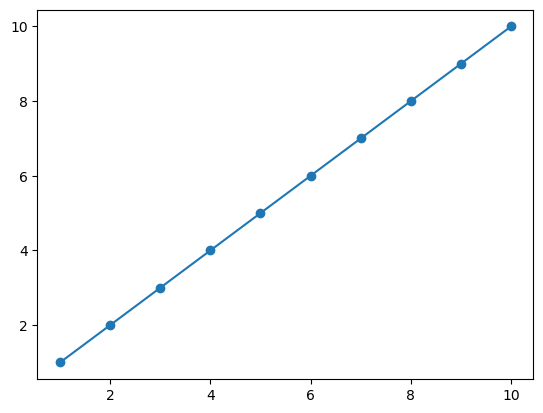

In [45]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

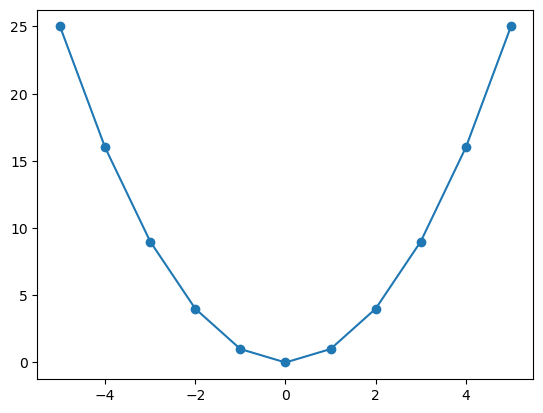

In [15]:
x=range(-5,6)
y=np.square(x)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

In [52]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [18]:
col1=visa_data['no_of_employees']
col2=visa_data['yr_of_estab']
col3=visa_data['prevailing_wage']

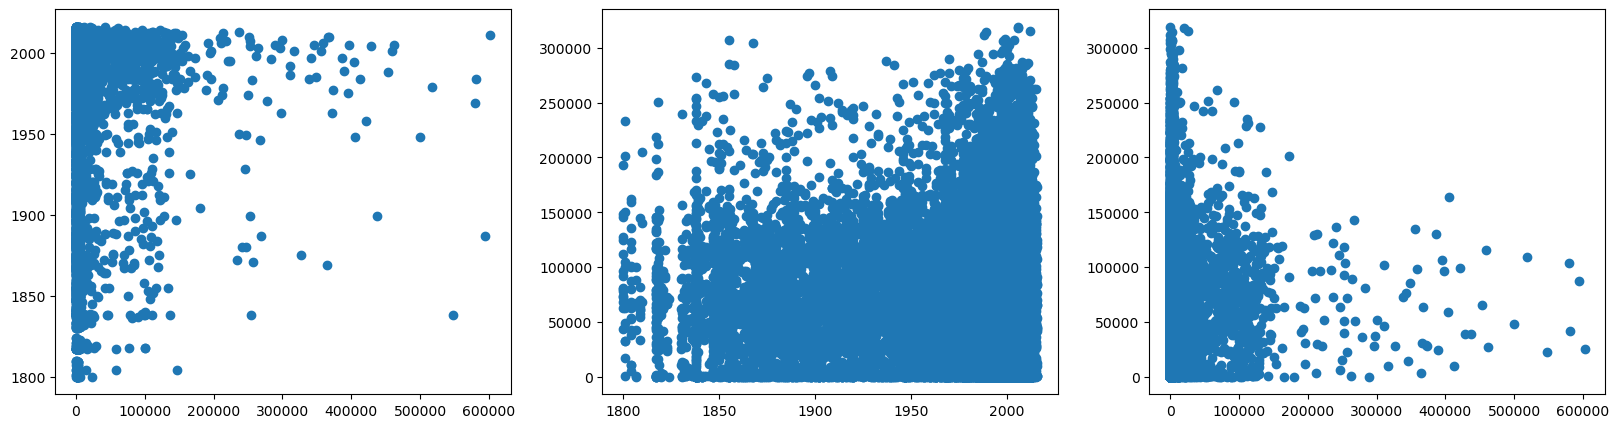

In [19]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)
plt.show()

- we have draw the scatter plots for numeric columns
- by seeing above plots we are not able to identify the relationship
- to get more confidence we will go to correlation matrix


In [7]:
visa_data.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


**all the columns are independent to eachother**

In [9]:
# wine quality dataset 
# read the dataframe and perform the correlation matrix
# do your analysis yourself immediately which columns has high +ve -ve relation

In [10]:
wine_data=pd.read_csv(r"C:\Users\Suman\Documents\Naresh IT\data files\winequality_red.csv")

In [11]:
wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [12]:
wine_data.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


## **heatmap**

- so far whatever the plots we did same we can implement by using seaborn
- like barchart, countplot, histogram, didtribution, boxplot,,,

<Axes: >

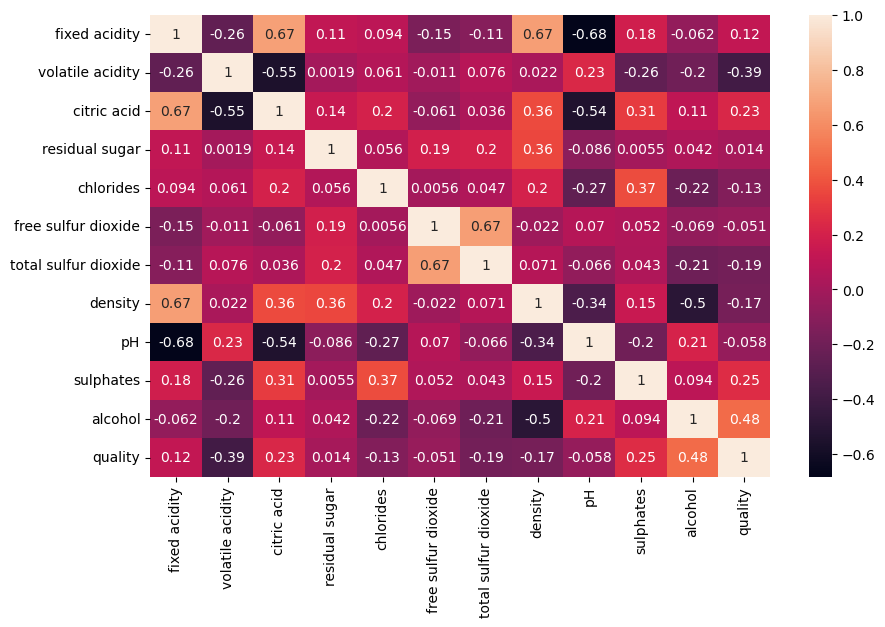

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(wine_data.corr()
           ,annot=True)